In [1]:
### Import Programmes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from sklearn.cluster import KMeans
from math import ceil

### Robot Sample Locations

In [2]:
# Build robot data table 
ranges = pd.read_csv('range.csv')
locations = pd.read_csv('robot_locations.csv')

robots = (
    locations.merge(ranges, on='index', how='inner')
    .rename(columns={'index': 'robot_id'})
    [['robot_id', 'longitude', 'latitude', 'range']]
    .sort_values('robot_id')
    .reset_index(drop=True)
)

#robots.to_csv('robot_table.csv', index=False)
robots.head()

,robot_id,longitude,latitude,range
0,0,-120.240815,-79.238374,127.868274
1,1,-134.537839,-83.426214,87.246488
2,2,-105.282215,-84.681705,64.393799
3,3,-105.453243,-77.964007,100.815352
4,4,-168.816260,-86.934888,36.021544


Number of robots: 1072
Longitude range: -179.589 to 179.986
Latitude range: -89.992 to -63.988
Robot range: 10.743 to 173.899


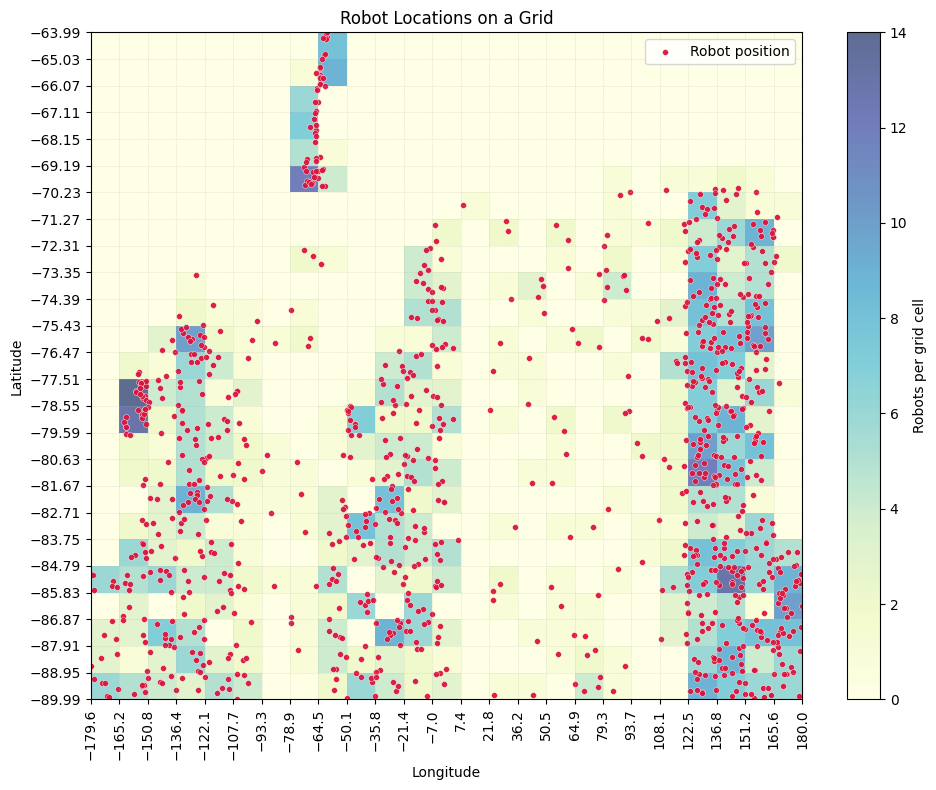

In [3]:
print(f'Number of robots: {len(robots)}')
print(f'Longitude range: {robots.longitude.min():.3f} to {robots.longitude.max():.3f}')
print(f'Latitude range: {robots.latitude.min():.3f} to {robots.latitude.max():.3f}')
print(f'Robot range: {robots["range"].min():.3f} to {robots["range"].max():.3f}')

grid_size = 25
lon_edges = np.linspace(robots['longitude'].min(), robots['longitude'].max(), grid_size + 1)
lat_edges = np.linspace(robots['latitude'].min(), robots['latitude'].max(), grid_size + 1)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.hist2d(
    robots['longitude'],
    robots['latitude'],
    bins=[lon_edges, lat_edges],
    cmap='YlGnBu',
    alpha=0.65
)
ax.scatter(
    robots['longitude'],
    robots['latitude'],
    s=18,
    c='crimson',
    edgecolors='white',
    linewidths=0.3,
    marker='o',
    alpha=0.95,
    label='Robot position'
)
plt.colorbar(heatmap[3], ax=ax, label='Robots per grid cell')
ax.set_title('Robot Locations on a Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks(lon_edges)
ax.set_yticks(lat_edges)
ax.tick_params(axis='x', labelrotation=90)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
#fig.savefig("Graphs/robot_locations.png", dpi=300, bbox_inches="tight")
plt.show()



In [4]:
# Random sample of robots

robots_subset = robots.sample(n=100, random_state=1).reset_index(drop=True).copy()

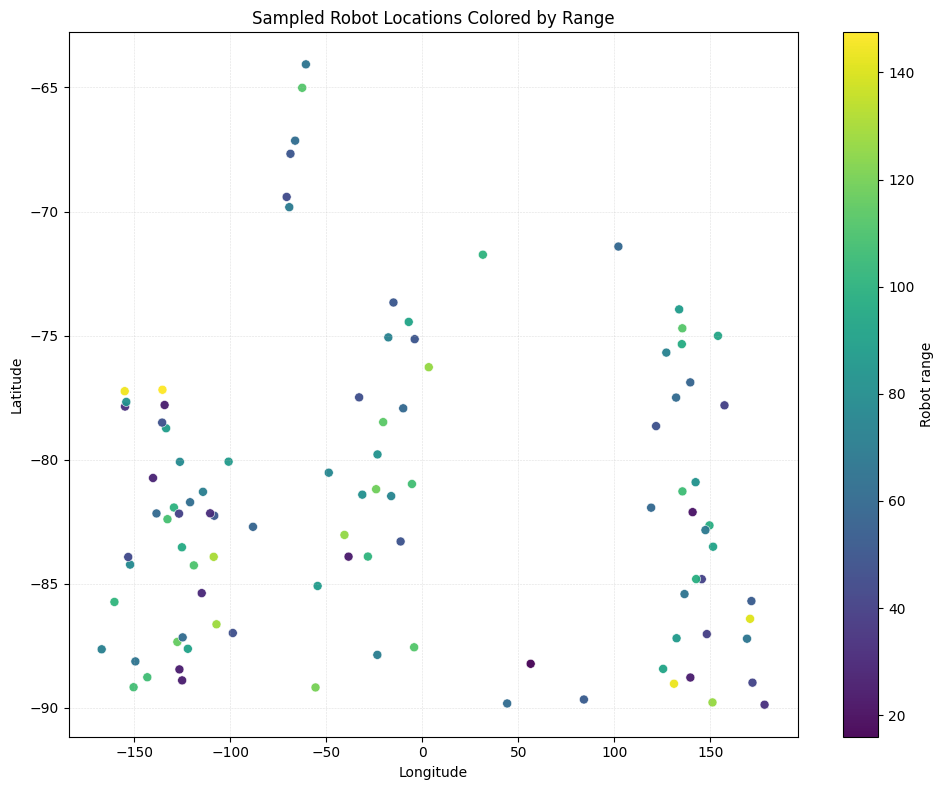

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    robots_subset['longitude'],
    robots_subset['latitude'],
    c=robots_subset['range'],
    cmap='viridis',
    s=42,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.95
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Robot range')
ax.set_title('Sampled Robot Locations Colored by Range')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
plt.tight_layout()
#fig.savefig("Graphs/sampled_robots_500.png", dpi=300, bbox_inches="tight")
plt.show()


### Candidate Locations

Candidate charging locations are generated using a multi-scale weighted k-means procedure applied to the sampled robot coordinates. 

First, only robot longitude and latitude are used as clustering inputs, while each robot is given a weight equal to the inverse of its range, so that robots with smaller ranges exert greater influence on the cluster centres. The aim of these weights is to reduce the likelihood a candidate location falls outside of any robots range

The clustering is then repeated for target group sizes from 1 to 16: for each value s, the number of clusters is set to k = ceil(n / s), where n is the number of sampled robots, so that the average cluster contains about s robots. These values are chosen because with our given parameters, between 1 and 16 robots can be allocated to any charger.

For each run, the weighted k-means cluster centres are recorded as candidate charging locations, together with the corresponding source group size and realized cluster size. After combining the centres from all 16 runs, duplicate candidate locations are removed by rounding longitude and latitude and dropping repeated points. (We round to 4dp which is equivalent to approximately 5.5m in real distance).

The result is a multi-resolution candidate set containing both fine local candidate locations and broader regional candidate locations, with additional emphasis placed on robots with shorter ranges.

In [6]:
coords = robots_subset[["longitude", "latitude"]].to_numpy() # robot coordinates

# Higher weight for smaller-range robots
weights = 1.0 / np.maximum(robots_subset["range"].to_numpy(), 1e-6) # weights inversely proportional to range

candidate_rows = [] # stores candidate locations
candidate_id = 0 # to give each candidate a unique ID

# Generate candidate locations using KMeans clustering for group sizes 1 to 16
for s in range(1, 17):
    k = ceil(len(robots_subset) / s) # number of clusters based on group size s

    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(coords, sample_weight=weights)

    centers = km.cluster_centers_
    labels = km.labels_

    for cluster_idx in range(k):
        cluster_size = int(np.sum(labels == cluster_idx))
        center = centers[cluster_idx]

        candidate_rows.append({
            "candidate_id": candidate_id,
            "source_group_size": s,
            "cluster_size": cluster_size,
            "longitude": float(center[0]),
            "latitude": float(center[1])
        })
        candidate_id += 1

candidate_locations = pd.DataFrame(candidate_rows)

display(candidate_locations.head(20))
print("Number of candidate locations before deduplication:", len(candidate_locations))

,candidate_id,source_group_size,cluster_size,longitude,latitude
0,0,1,1,-16.249279,-81.470146
1,1,1,1,149.578195,-82.651637
2,2,1,1,-132.796099,-82.401487
3,3,1,1,56.426577,-88.229542
4,4,1,1,-69.331545,-69.824598
5,5,1,1,-114.954454,-85.381265
6,6,1,1,-149.516387,-88.133981
7,7,1,1,139.618091,-88.782956
8,8,1,1,171.426841,-85.701328
9,9,1,1,102.125240,-71.411317


Number of candidate locations before deduplication: 345


In [7]:
candidate_locations["lon_r"] = candidate_locations["longitude"].round(4)
candidate_locations["lat_r"] = candidate_locations["latitude"].round(4)

candidate_locations = (
    candidate_locations
    .drop_duplicates(subset=["lon_r", "lat_r"])
    .drop(columns=["lon_r", "lat_r"])
    .reset_index(drop=True)
)

candidate_locations["candidate_id"] = range(len(candidate_locations))


In [8]:
print("Number of candidate locations:", len(candidate_locations))
print("Candidates before deduplication:", len(pd.DataFrame(candidate_rows)))
print("Candidates after deduplication:", len(candidate_locations))
print(candidate_locations["source_group_size"].value_counts().sort_index())


Number of candidate locations: 203
Candidates before deduplication: 345
Candidates after deduplication: 203
source_group_size
1     100
2      28
3      18
4      12
5       9
6       8
7       7
8       4
9       1
10      5
12      2
13      4
15      5
Name: count, dtype: int64


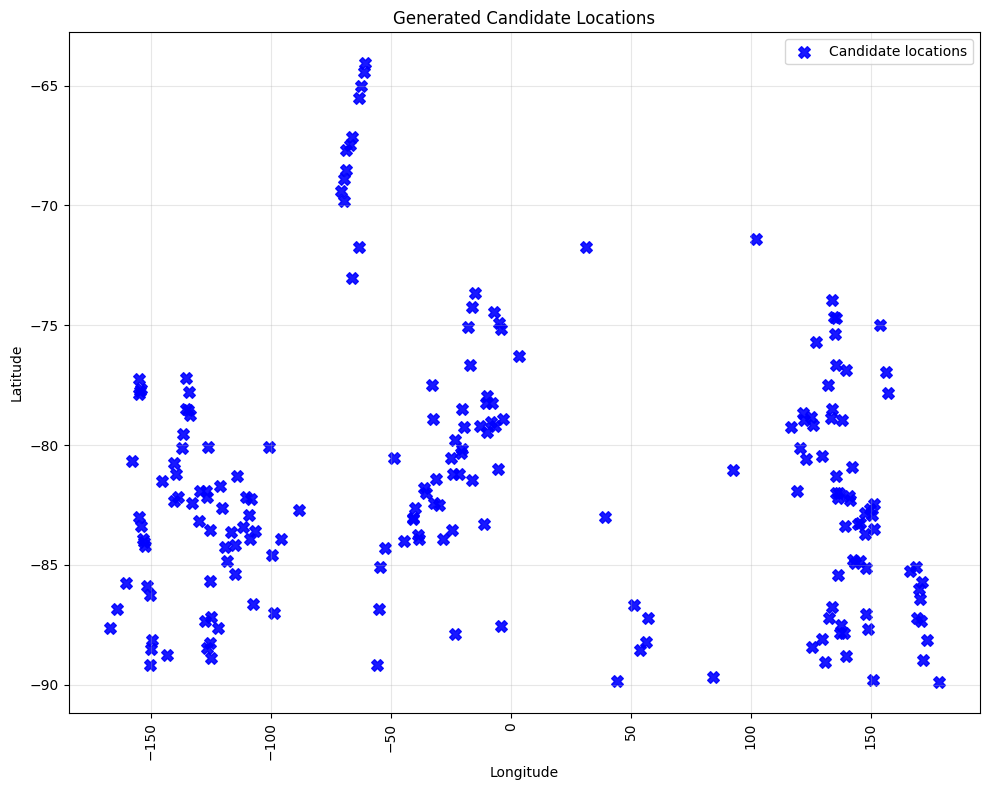

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))


# Plot candidate locations
ax.scatter(
    candidate_locations["longitude"],
    candidate_locations["latitude"],
    c="blue",
    s=70,
    marker="X",
    alpha=0.9,
    label="Candidate locations"
)

ax.set_title("Generated Candidate Locations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
#fig.savefig("Graphs/candidates_1a_1000.png", dpi=300, bbox_inches="tight")
plt.show()


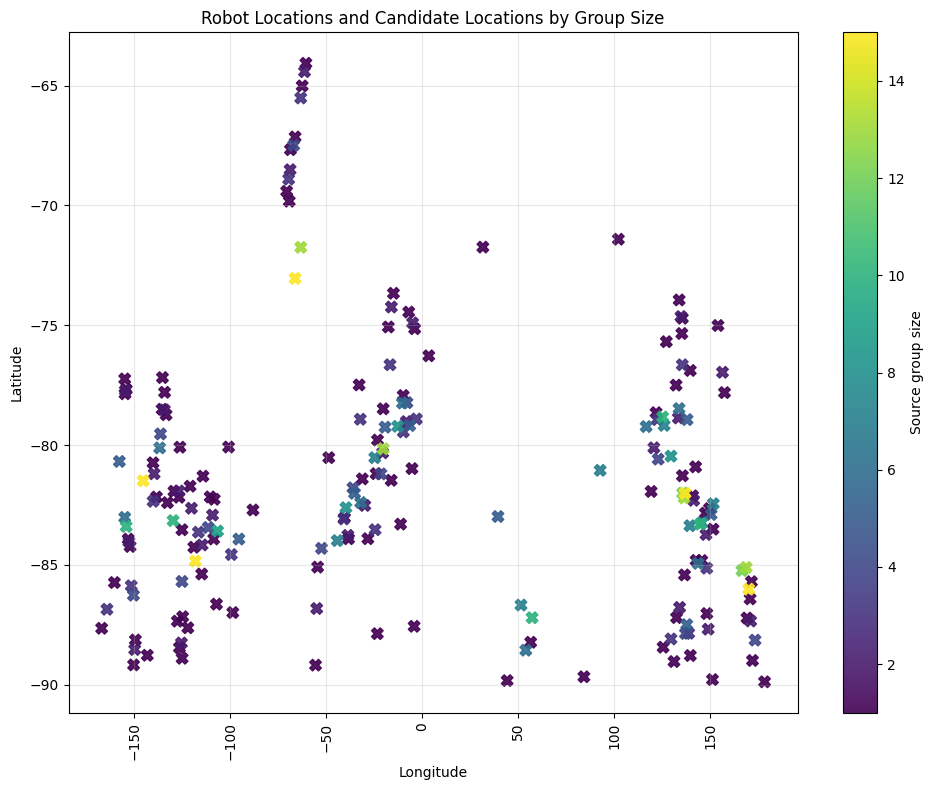

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    robots_subset["longitude"],
    robots_subset["latitude"],
    c="lightgray",
    s=25,
    alpha=0.6,
    label="Robots"
)

scatter = ax.scatter(
    candidate_locations["longitude"],
    candidate_locations["latitude"],
    c=candidate_locations["source_group_size"],
    cmap="viridis",
    s=70,
    marker="X",
    alpha=0.9
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Source group size")

ax.set_title("Robot Locations and Candidate Locations by Group Size")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Model

### Decision Variables

- $y_j \in \{0,1\}$: equals 1 if candidate station $j$ is opened  
- $z_j \in \mathbb{Z}_+$: number of chargers at station $j$  
- $x_{ij} \in \{0,1\}$: equals 1 if robot $i$ is assigned to station $j$  


### Parameters

- $I$: set of robots  
- $J$: set of candidate station locations  
- $d_{ij}$: distance from robot $i$ to station $j$  
- $r_i$: range of robot $i$  
- $m$: maximum number of chargers per station  
- $q$: maximum number of robots per charger  
- $c_b$: build cost per station  
- $c_m$: maintenance cost per charger  
- $c_c$: charging cost per km  
- $c_h$: transport cost if robot cannot reach a station  
- $r_{\max}$: maximum charge level after recharging  
- $T = 365$: planning horizon (days)  

Define:

$$
u_{ij} =
\begin{cases}
1 & \text{if } d_{ij} > r_i \\
0 & \text{otherwise}
\end{cases}
$$

As we have a finite set of candidate locations, we define the distances between all robots and candidate locations (d[i,j]) in preprocessing. We do the same for whether a candidate location is within the range of a robot too (u[i,j]). 


### Constraints

#### Assignment

Each robot must be assigned to exactly one station:

$$
\sum_{j \in J} x_{ij} = 1 \quad \forall i \in I
$$



#### Station Opening

A robot can only be assigned to an open station:

$$
x_{ij} \leq y_j \quad \forall i \in I,\; j \in J
$$



#### Capacity

Each charger can serve at most $q$ robots:

$$
\sum_{i \in I} x_{ij} \leq q \cdot z_j \quad \forall j \in J
$$



#### Charger Limit

Each station can have at most $m$ chargers:

$$
z_j \leq m \cdot y_j \quad \forall j \in J
$$



#### Optional Constraint

If a station is opened, it must have at least one charger:

$$
z_j \geq y_j \quad \forall j \in J
$$

Note that this constraint does not need to be used as it by wanting to minimise the costs as the objective, a station will never be built without a charger also being built. It can stengthen formulation of the model though. 


### Objective Function

Minimize total annual cost:

$$
\min \sum_{j \in J} \left( c_b y_j + c_m z_j \right)
+ T \sum_{i \in I} \sum_{j \in J}
\Big[
c_c \big( (r_{\max} - r_i + d_{ij})(1 - u_{ij}) + (r_{\max} - r_i)u_{ij} \big)
+ c_h u_{ij}
\Big] x_{ij}
$$


### Interpretation of Cost

- If $d_{ij} \leq r_i$ (reachable), then $u_{ij} = 0$ and:

$$
\text{cost} = c_c (r_{\max} - r_i + d_{ij})
$$

- If $d_{ij} > r_i$ (unreachable), then $u_{ij} = 1$ and:

$$
\text{cost} = c_c (r_{\max} - r_i) + c_h
$$


### Summary

The model determines:

- Which stations to open  
- How many chargers to install at each station  
- How to assign robots to stations  

while minimizing total annual cost subject to assignment, capacity, and feasibility constraints.

In [11]:
# Model parameters
planning_days = 365
m = 8
q = 2
c_b = 5000
c_h = 1000
c_m = 500
c_c = 0.42
lambda_ = 0.012
r_min = 10
r_max = 175

robots_model = robots_subset.copy().reset_index(drop=True)
stations_model = candidate_locations.copy().reset_index(drop=True)

distance_records = []

for _, robot in robots_model.iterrows():
    for _, station in stations_model.iterrows():
        d_ij = np.sqrt(
            (robot["longitude"] - station["longitude"]) ** 2 +
            (robot["latitude"] - station["latitude"]) ** 2
        )
        distance_records.append({
            "robot_id": int(robot["robot_id"]),
            "candidate_id": int(station["candidate_id"]),
            "d_ij": float(d_ij),
            "range": float(robot["range"])
        })

distance_table = pd.DataFrame(distance_records)
distance_table["unreachable"] = (distance_table["d_ij"] > distance_table["range"]).astype(int)

print("Robots:", len(robots_model))
print("Candidate locations:", len(stations_model))
display(distance_table.head())
print("Robot-station pairs:", len(distance_table))



Robots: 100
Candidate locations: 203


,robot_id,candidate_id,d_ij,range,unreachable
0,120,0,91.158409,127.887414,0
1,120,1,256.870210,127.887414,1
2,120,2,25.884091,127.887414,0
3,120,3,163.695392,127.887414,1
4,120,4,41.489079,127.887414,0


Robot-station pairs: 20300


In [12]:
I = robots_model["robot_id"].astype(int).tolist()
J = stations_model["candidate_id"].astype(int).tolist()

range_dict = robots_model.set_index("robot_id")["range"].to_dict()

# Mapping: robot_id, candidate_id -> distance
distance_dict = {
    (int(row.robot_id), int(row.candidate_id)): float(row.d_ij)
    for row in distance_table.itertuples(index=False)
}

# Mapping: robot_id, candidate_id -> 0/1 for unreachable
unreachable_dict = {
    (int(row.robot_id), int(row.candidate_id)): int(row.unreachable)
    for row in distance_table.itertuples(index=False)
}

In [13]:
# Create Pyomo model
model = pyo.ConcreteModel()

# Sets
model.I = pyo.Set(initialize=I) # Set of robot IDs
model.J = pyo.Set(initialize=J) # Set of candidate station IDs

# Parameters
model.r = pyo.Param(model.I, initialize=range_dict) # Robot range parameter
model.d = pyo.Param(model.I, model.J, initialize=distance_dict) # Distance parameter
model.unreachable = pyo.Param(model.I, model.J, initialize=unreachable_dict, within=pyo.Binary) # Unreachable parameter

# Decision variables 
model.y = pyo.Var(model.J, domain=pyo.Binary) # y[j] = 1 if candidate station j is selected, 0 otherwise
model.z = pyo.Var(model.J, domain=pyo.NonNegativeIntegers) # z[j] = number of chargers at station j
model.x = pyo.Var(model.I, model.J, domain=pyo.Binary) # x[i,j] = 1 if robot i is assigned to station j, 0 otherwise

In [14]:
# Every robot must be assigned to exactly one station.
def assign_once_rule(model, i):
    return sum(model.x[i, j] for j in model.J) == 1
model.assign_once = pyo.Constraint(model.I, rule=assign_once_rule)

# A robot can only be assigned to a station if that station is built.
def open_link_rule(model, i, j):
    return model.x[i, j] <= model.y[j]
model.open_link = pyo.Constraint(model.I, model.J, rule=open_link_rule)

# Number of robots assigned to station j cannot exceed the number of chargers built at station j times the charger capacity q.
def charger_capacity_rule(model, j):
    return sum(model.x[i, j] for i in model.I) <= q * model.z[j]
model.charger_capacity = pyo.Constraint(model.J, rule=charger_capacity_rule)

# Number of chargers built at station j cannot exceed the maximum number of chargers m times whether the station is built or not.
def charger_limit_rule(model, j):
    return model.z[j] <= m * model.y[j]
model.charger_limit = pyo.Constraint(model.J, rule=charger_limit_rule)

# If a station is built at candidate location j, it must have at least one charger.
# I dont think we need this as it wouldnt be optimal to build a station with zero chargers, but we can add it for completeness.
#def min_charger_if_open_rule(model, j):
 #   return model.z[j] >= model.y[j]
#model.min_charger_if_open = pyo.Constraint(model.J, rule=min_charger_if_open_rule)

print("Constraints added.")


Constraints added.


In [15]:
def objective_rule(model):

    # cost of building stations (c_b * y_j) and chargers (c_m * z_j) (paid one time per year)
    fixed_cost = sum(c_b * model.y[j] + c_m * model.z[j] for j in model.J)

    # If a robot is assigned to a station that is within its range, the cost is c_c * (r_max - r_i + d_ij) per day. 
    # If the station is out of range, the cost is c_c * (r_max - r[i]) per day (since the robot would have to be transported to a station within range).
    charging_cost = planning_days * sum(
        c_c * (
            (r_max - model.r[i] + model.d[i, j]) * (1 - model.unreachable[i, j])
            + (r_max - model.r[i]) * model.unreachable[i, j]
        ) * model.x[i, j]
        for i in model.I for j in model.J
    )

    # If a robot is assigned to a station that is out of range, there is an additional transport cost of c_h per day.
    transport_cost = planning_days * sum(
        c_h * model.unreachable[i, j] * model.x[i, j]
        for i in model.I for j in model.J
    )

    return fixed_cost + charging_cost + transport_cost

model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

print("Objective added.")


Objective added.


In [16]:
solver = pyo.SolverFactory("gurobi")

if not solver.available(False):
    raise RuntimeError("Gurobi is not available in this environment.")

solver.options["TimeLimit"] = 300
#solver.options["MIPGap"] = 0.01

results = solver.solve(model, tee=True)

print("Status:", results.solver.status)
print("Termination:", results.solver.termination_condition)

if results.solver.termination_condition in {
    pyo.TerminationCondition.optimal,
    pyo.TerminationCondition.locallyOptimal,
    pyo.TerminationCondition.feasible,
}:
    print("Objective value:", pyo.value(model.obj))
else:
    print("No usable solution returned.")


Read LP format model from file C:\Users\asher\AppData\Local\Temp\tmpqesn1i2u.pyomo.lp
Reading time = 0.15 seconds
x1: 20806 rows, 20706 columns, 81809 nonzeros
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 20806 rows, 20706 columns and 81809 nonzeros (Min)
Model fingerprint: 0xf6e3bac8
Model has 20706 linear objective coefficients
Variable types: 0 continuous, 20706 integer (20503 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [5e+02, 4e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 2.546712e+07
Presolve time: 0.37s
Presolved: 20806 rows, 20706 columns, 81809 nonzeros
Variable types: 0 continu

### Results

In [17]:
built_stations = []
for j in model.J:
    if pyo.value(model.y[j]) > 0.5:
        station_row = stations_model[stations_model["candidate_id"] == j].iloc[0]
        built_stations.append({
            "candidate_id": j,
            "longitude": station_row["longitude"],
            "latitude": station_row["latitude"],
            "chargers": int(round(pyo.value(model.z[j])))
        })

built_stations_df = pd.DataFrame(built_stations)
display(built_stations_df)

assignments = []
for i in model.I:
    for j in model.J:
        if pyo.value(model.x[i, j]) > 0.5:
            assignments.append({
                "robot_id": i,
                "candidate_id": j,
                "distance": float(pyo.value(model.d[i, j])),
                "range": float(pyo.value(model.r[i])),
                "needs_transport": int(model.unreachable[i, j])
            })

assignments_df = pd.DataFrame(assignments)
display(assignments_df.head(20))


,candidate_id,longitude,latitude,chargers
0,9,102.125240,-71.411317,1
1,21,-108.710986,-83.918674,5
2,27,-24.096200,-81.193559,5
3,29,44.181625,-89.828908,2
4,41,-153.239027,-83.925327,5
5,77,-66.295566,-67.143885,3
6,97,170.731742,-86.416711,3
7,101,133.382433,-78.869919,7
8,106,147.780424,-83.731384,6
9,107,-134.422316,-78.534217,4


,robot_id,candidate_id,distance,range,needs_transport
0,120,21,3.081810,127.887414,0
1,552,101,1.820069,60.391929,0
2,90,21,0.000000,130.136422,0
3,973,77,6.405120,65.957089,0
4,667,106,2.463889,41.008548,0
5,314,160,10.127261,50.515308,0
6,181,21,6.412493,30.119770,0
7,119,41,11.060891,106.700303,0
8,49,147,3.207426,25.688149,0
9,101,107,6.296179,28.071125,0


In [18]:
def _as_float(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None

number_of_robots = len(model.I)
number_of_stations = int(round(sum(pyo.value(model.y[j]) for j in model.J)))
number_of_chargers = int(round(sum(pyo.value(model.z[j]) for j in model.J)))

buildings_cost = sum(
    c_b * pyo.value(model.y[j]) + c_m * pyo.value(model.z[j])
    for j in model.J
)

assignment_cost = planning_days * sum(
    c_c * (
        (r_max - pyo.value(model.r[i]) + pyo.value(model.d[i, j])) * (1 - pyo.value(model.unreachable[i, j]))
        + (r_max - pyo.value(model.r[i])) * pyo.value(model.unreachable[i, j])
    ) * pyo.value(model.x[i, j])
    for i in model.I for j in model.J
)

transport_cost = planning_days * sum(
    c_h * pyo.value(model.unreachable[i, j]) * pyo.value(model.x[i, j])
    for i in model.I for j in model.J
)

total_cost = pyo.value(model.obj)
robots_needing_transport = int(assignments_df["needs_transport"].sum()) if not assignments_df.empty else 0

lower_bound = _as_float(getattr(results.problem, "lower_bound", None))
upper_bound = _as_float(getattr(results.problem, "upper_bound", None))
mip_gap = _as_float(getattr(results.solver, "mip_gap", None))

if mip_gap is None:
    mip_gap = _as_float(getattr(results.solver, "gap", None))

if mip_gap is None and lower_bound is not None and upper_bound is not None:
    mip_gap = abs(upper_bound - lower_bound) / max(abs(upper_bound), 1e-9)

results_summary = pd.DataFrame([
    {
        "Number of robots": number_of_robots,
        "Number of stations": number_of_stations,
        "Number of chargers": number_of_chargers,
        "Total cost": total_cost,
        "Assignment cost": assignment_cost,
        "Buildings cost": buildings_cost,
        "Transport cost": transport_cost,
        "Robots needing transport": robots_needing_transport,
        "MIP gap": mip_gap,
        "MIP gap (%)": None if mip_gap is None else 100 * mip_gap,
    }
])

results_summary_display = pd.DataFrame([
    {"Metric": "Number of robots", "Value": f"{number_of_robots:,.0f}"},
    {"Metric": "Number of stations", "Value": f"{number_of_stations:,.0f}"},
    {"Metric": "Number of chargers", "Value": f"{number_of_chargers:,.0f}"},
    {"Metric": "Total cost", "Value": f"{total_cost:,.2f}"},
    {"Metric": "Assignment cost", "Value": f"{assignment_cost:,.2f}"},
    {"Metric": "Buildings cost", "Value": f"{buildings_cost:,.2f}"},
    {"Metric": "Transport cost", "Value": f"{transport_cost:,.2f}"},
    {"Metric": "Robots needing transport", "Value": f"{robots_needing_transport:,.0f}"},
    {"Metric": "MIP gap", "Value": "N/A" if mip_gap is None else f"{mip_gap:.6f}"},
    {"Metric": "MIP gap (%)", "Value": "N/A" if mip_gap is None else f"{100 * mip_gap:.4f}%"},
])

display(results_summary_display)


,Metric,Value
0,Number of robots,100
1,Number of stations,13
2,Number of chargers,52
3,Total cost,"1,705,053.85"
4,Assignment cost,"1,614,053.85"
5,Buildings cost,"91,000.00"
6,Transport cost,0.00
7,Robots needing transport,0
8,MIP gap,0.000000
9,MIP gap (%),0.0000%


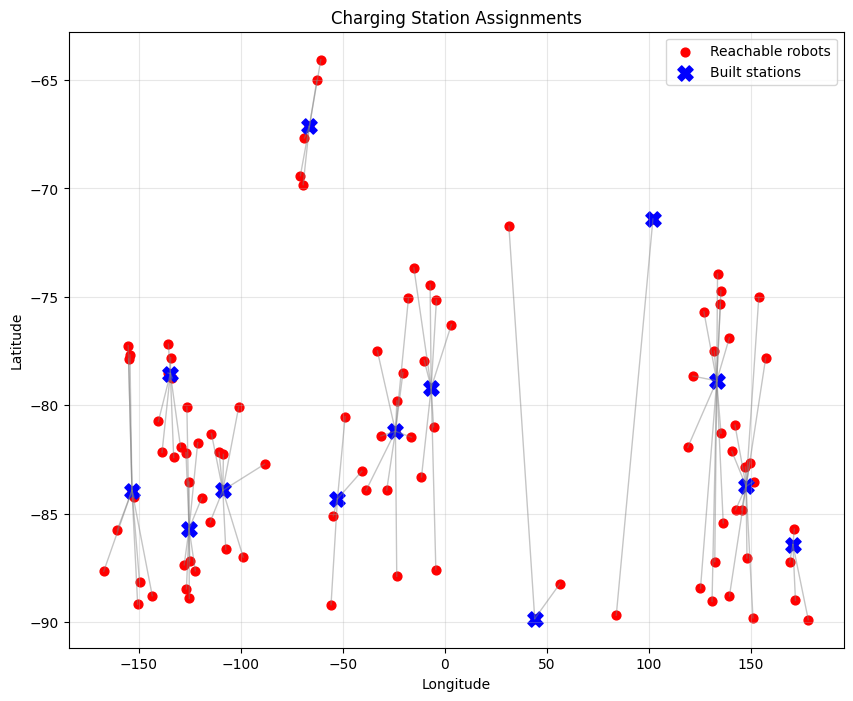

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

transport_robot_ids = set(assignments_df.loc[assignments_df["needs_transport"] == 1, "robot_id"])

reachable_robots = robots_model[~robots_model["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_model[robots_model["robot_id"].isin(transport_robot_ids)]

ax.scatter(
    reachable_robots["longitude"],
    reachable_robots["latitude"],
    c="red",
    s=40,
    label="Reachable robots"
)

if not transport_robots.empty:
    ax.scatter(
        transport_robots["longitude"],
        transport_robots["latitude"],
        c="orange",
        s=55,
        label="Transport-needed robots"
    )

if not built_stations_df.empty:
    ax.scatter(
        built_stations_df["longitude"],
        built_stations_df["latitude"],
        c="blue",
        s=120,
        marker="X",
        label="Built stations"
    )

    for _, row in assignments_df.iterrows():
        station = built_stations_df[
            built_stations_df["candidate_id"] == row["candidate_id"]
        ].iloc[0]

        robot = robots_model[
            robots_model["robot_id"] == row["robot_id"]
        ].iloc[0]

        line_color = "darkorange" if row["needs_transport"] == 1 else "gray"

        ax.plot(
            [robot["longitude"], station["longitude"]],
            [robot["latitude"], station["latitude"]],
            color=line_color,
            alpha=0.45,
            linewidth=1
        )

ax.set_title("Charging Station Assignments")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
#fig.savefig("Graphs/assignments_1a_1000.png", dpi=300, bbox_inches="tight")
plt.show()
